<h3 style="color:#1A5276;">Q1. Can we predict COVID positivity based on age, symptoms, testing behavior and household exposure?</h3>



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

In [13]:
covid_df_cleaned= pd.read_csv("covid_df_cleaned.csv")
df_pred = covid_df_cleaned[
    ['covid_status', 'age', 'tested', 'cough',
     'fever_chills_shakes', 'shortness_of_breath',
     'contact_in_household', 'any_medical_conditions',
     'vulnerable']
].copy()

# Normalize covid_status
df_pred['covid_status'] = (
    df_pred['covid_status']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_pred = df_pred[df_pred['covid_status'].isin(['positive','negative'])]

# Fill missing values
for col in df_pred.columns:
    df_pred[col] = df_pred[col].fillna('unknown')

# Encode target
df_pred['covid_status'] = df_pred['covid_status'].map({
    'positive': 1,
    'negative': 0
})
X = df_pred.drop('covid_status', axis=1)
y = df_pred['covid_status']

X_encoded = pd.get_dummies(X, drop_first=True)

print("Final sample count:", X_encoded.shape[0])
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


C:\Users\gowri\AppData\Local\Temp\ipykernel_1216\778118965.py:1: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df_cleaned= pd.read_csv("covid_df_cleaned.csv")


Final sample count: 490
Accuracy: 0.9523809523809523
ROC AUC: 0.735204081632653

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       140
           1       0.00      0.00      0.00         7

    accuracy                           0.95       147
   macro avg       0.48      0.50      0.49       147
weighted avg       0.91      0.95      0.93       147



<function matplotlib.pyplot.show(close=None, block=None)>

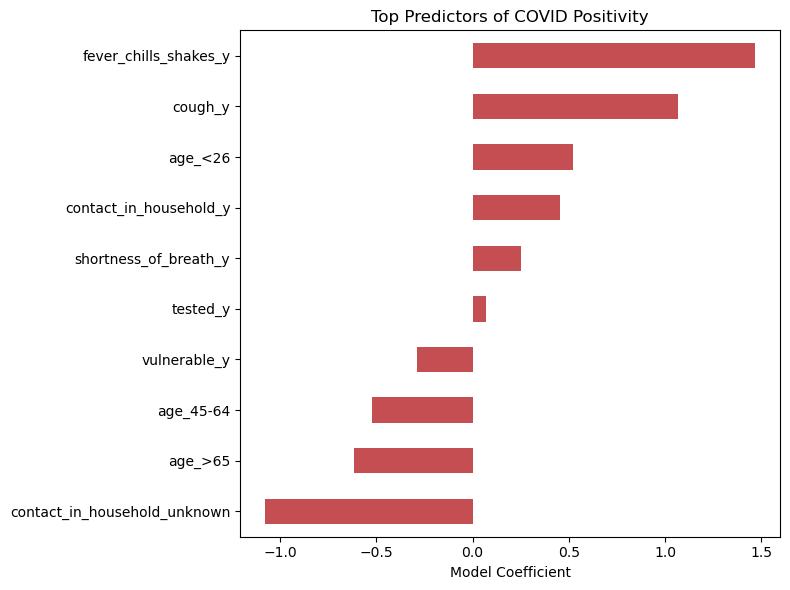

In [14]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.coef_[0],
    index=X_encoded.columns
).sort_values()

plt.figure(figsize=(8,6))
feature_importance.tail(10).plot(kind='barh', color='#C44E52')
plt.title("Top Predictors of COVID Positivity")
plt.xlabel("Model Coefficient")
plt.tight_layout()
plt.show

<h3 style="color:#1A5276;">Predictive Analysis: Predicting covid positivity status?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>Healthcare planning: We can use the predicted weekly cases to estimate resource needs (beds, testing kits).
Trend monitoring: The model can help spot upward trends early, even before actual case counts spike. 
Using this graph we can forecast Covid positivity trend when a new variant arrives and can be prepared with essential resources.
</p>

In [15]:
# Example: Aggregate the number of positive COVID cases per week
weekly_data = df[df['covid_status']=='Positive'].groupby('week').size().reset_index(name='positive_cases')

# Rename columns for Prophet
weekly_data.rename(columns={'week':'ds', 'positive_cases':'y'}, inplace=True)

# Convert week number to datetime with reference year 2020
weekly_data['ds'] = weekly_data['ds'].apply(lambda w: pd.to_datetime(f'2020-{int(w)}-3', format='%Y-%U-%w'))


In [16]:
pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.1 MB 14.6 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/12.1 MB 19.3 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 23.1 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 20.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 27.3 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 

In [17]:
from prophet import Prophet

# Initialize model
model = Prophet(weekly_seasonality=True)
model.fit(weekly_data)

# Create future weeks dataframe
future = model.make_future_dataframe(periods=8, freq='W')  # Forecast next 8 weeks

# Forecast
forecast = model.predict(future)

23:55:12 - cmdstanpy - INFO - Chain [1] start processing
23:55:13 - cmdstanpy - INFO - Chain [1] done processing


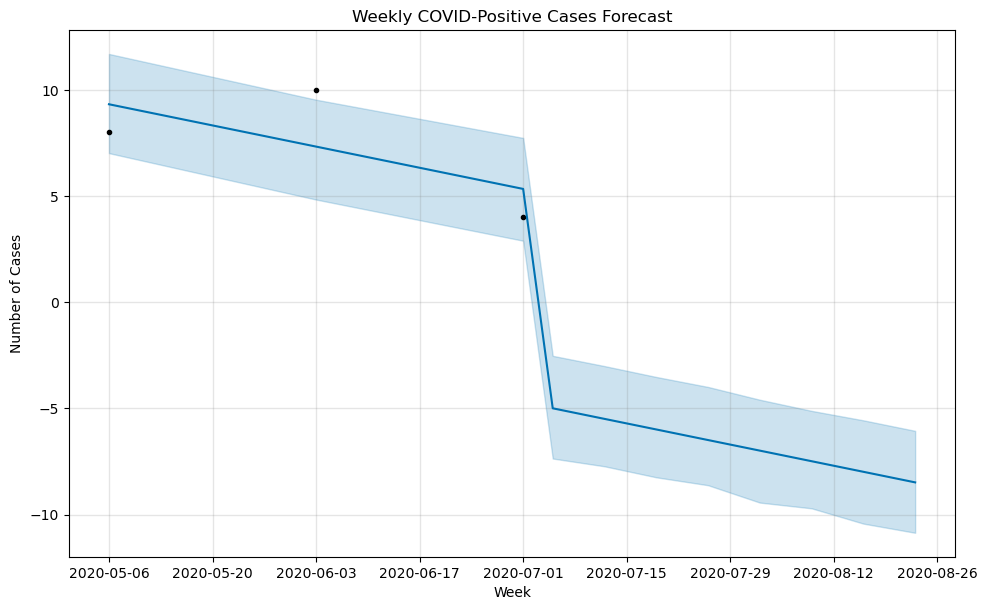

In [18]:
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt

# Plot using matplotlib
model.plot(forecast)
plt.title("Weekly COVID-Positive Cases Forecast")
plt.xlabel("Week")
plt.ylabel("Number of Cases")
plt.show()
